# Aboveground Carbon RF Model — Results Summary
**Model:** exp_agc — Random Forest regression on aboveground forest carbon
**Target:** C_AGC_KGM2 (kgC/m²) from Jenkins et al. (2003) allometric equations
**CV method:** GroupKFold (n=5) by polygon ID

## Process Summary
1. Random points generated in DNR Forest Stand Inventory polygons (1 pt/2 acres, min 1, max 50)
2. Subsampled to 50,000 points stratified by Jenkins species group
3. Covariates extracted using batch rasterio.sample() — one raster open per covariate
4. RFE with GroupKFold — groups prevent same-polygon points leaking across folds
5. Final model trained on 50k points with 300 trees

## Why GroupKFold matters
Each polygon contributes multiple points with identical target values.
Standard random KFold would put some of those points in training and some in validation,
giving artificially high R² since the model effectively memorizes polygon values.
GroupKFold ensures ALL points from one polygon go to the same fold.


In [2]:
# Cell 1 — Load results
import json, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

BASE_M  = '/scratch.global/ocon0444/peat_modeling'
MDL_DIR = f'{BASE_M}/03_models/exp_agc'
RES_DIR = f'{BASE_M}/05_results/exp_agc'
OUT_DIR = f'{BASE_M}/00_data/processed'

# Load model and features
with open(f'{MDL_DIR}/agc_jenkins_rf_features.json') as f:
    meta = json.load(f)
with open(f'{RES_DIR}/rfe_agc.json') as f:
    rfe = json.load(f)

print('Model features:', meta['features'])
print(f'N features: {len(meta["features"])}')
print(f'RFE best R2: {rfe["R2"]:.4f}')
print(f'RFE best MAE: {rfe["MAE"]:.4f} kgC/m2')


Model features: ['minnesota_dem_10m', 'relativeTopographicPosition_4m', 'relativeTopographicPosition_8m', 'relativeTopographicPosition_16m', 'dist_to_water_10m', 'dist_to_stream_10m', 'dist_to_road_detailed_10m', 'dist_from_waterbody_edge_10m', 'prism_ppt_mn', 'prism_tmax_july_mn', 'prism_tmean_mn', 'prism_tmin_january_mn', 'slope', 'aspect', 'wetnessIndex', 'diffFromMeanElev', 'devfrommeanelev_4m', 'devfrommeanelev_8m', 'devfrommeanelev_16m', 'planCurvature', 'profileCurvature', 'maximalCurvature', 'geomorphons', 'mn_nwi_binary', 's2_spring_B02', 's2_spring_B03', 's2_spring_B04', 's2_spring_B05', 's2_spring_B06', 's2_spring_B07', 's2_spring_B08', 's2_spring_B8A', 's2_spring_B11', 's2_spring_B12', 's2_spring_NDVI', 's2_spring_SWDI', 's2_summer_B02', 's2_summer_B03', 's2_summer_B04', 's2_summer_B05', 's2_summer_B06', 's2_summer_B07', 's2_summer_B08', 's2_summer_B8A', 's2_summer_B11', 's2_summer_B12', 's2_summer_NDVI', 's2_summer_SWDI', 's2_fall_B02', 's2_fall_B03', 's2_fall_B04', 's2_fa

In [3]:
# Cell 2 — Load training data and reproduce CV predictions

feat_df = pd.read_csv(f'{OUT_DIR}/agc_features_extracted3.csv', low_memory=False)
TARGET  = 'C_AGC_KGM2'

NON_FEAT = ['x','y','C_AGC_KGM2','STAND_KEY','MN_SPP',
             'BASAL_AREA','JENKINS_GR','AREA_ACRES','exp410_prob',
             'mn_nwi_cowardin_raw']
LEAKERS  = ['histosol','npc_peat','MN_organic','MN_ANY','gNATSGO']

best_features = meta['features']
df_train = feat_df.dropna(subset=best_features + [TARGET]).copy()
print(f'Training rows: {len(df_train):,}')
print(f'Unique polygons: {df_train["STAND_KEY"].nunique():,}')
print(f'\nTarget (C_AGC_KGM2) distribution:')
print(f'  Mean:   {df_train[TARGET].mean():.3f} kgC/m2  ({df_train[TARGET].mean()*10:.1f} MgC/ha)')
print(f'  Median: {df_train[TARGET].median():.3f} kgC/m2')
print(f'  Std:    {df_train[TARGET].std():.3f} kgC/m2')
print(f'  Min:    {df_train[TARGET].min():.3f}')
print(f'  Max:    {df_train[TARGET].max():.3f}')

print('\nSpecies group breakdown:')
for grp, n in df_train['JENKINS_GR'].value_counts().items():
    mean_agc = df_train[df_train['JENKINS_GR']==grp][TARGET].mean()
    print(f'  {grp:<20}: n={n:>6,}  mean AGC={mean_agc:.3f} kgC/m2  ({mean_agc*10:.1f} MgC/ha)')


Training rows: 49,994
Unique polygons: 35,588

Target (C_AGC_KGM2) distribution:
  Mean:   2.714 kgC/m2  (27.1 MgC/ha)
  Median: 2.707 kgC/m2
  Std:    1.949 kgC/m2
  Min:    0.009
  Max:    75.326

Species group breakdown:
  spruce_fir          : n=16,637  mean AGC=2.397 kgC/m2  (24.0 MgC/ha)
  aspen               : n=15,609  mean AGC=2.226 kgC/m2  (22.3 MgC/ha)
  cedar_larch         : n= 4,683  mean AGC=4.065 kgC/m2  (40.6 MgC/ha)
  hard_maple          : n= 4,429  mean AGC=4.438 kgC/m2  (44.4 MgC/ha)
  pine                : n= 3,546  mean AGC=2.406 kgC/m2  (24.1 MgC/ha)
  mixed_hardwood      : n= 2,810  mean AGC=3.043 kgC/m2  (30.4 MgC/ha)
  soft_maple          : n= 1,383  mean AGC=3.436 kgC/m2  (34.4 MgC/ha)
  none                : n=   890  mean AGC=0.570 kgC/m2  (5.7 MgC/ha)
  woodland            : n=     7  mean AGC=2.457 kgC/m2  (24.6 MgC/ha)


Running GroupKFold CV (100 trees for speed)...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

GroupKFold CV Results:
  R²:              0.1990
  MAE:             1.3063 kgC/m2  (13.06 MgC/ha)
  RMSE:            1.7442 kgC/m2
  Mean residual:   0.0344 (bias)
  Relative MAE:    48.1% of mean


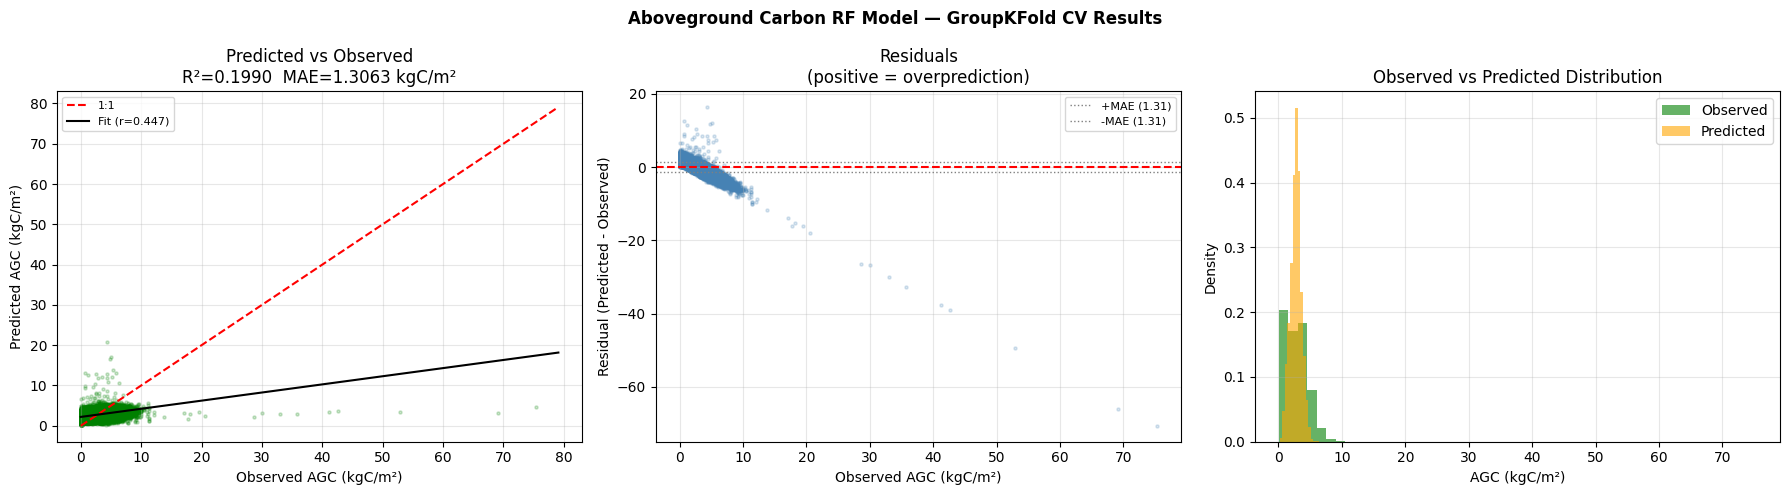

Saved: agc_rf_cv_results.png


In [4]:
# Cell 3 — Reproduce OOF predictions and plot results

X      = df_train[best_features].values
y      = df_train[TARGET].values
groups = df_train['STAND_KEY'].values
gkf    = GroupKFold(n_splits=5)

print('Running GroupKFold CV (100 trees for speed)...')
oof = np.zeros(len(y))
for fold_i, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups)):
    rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    rf.fit(X[tr_idx], y[tr_idx])
    oof[va_idx] = rf.predict(X[va_idx])
    print(f'  Fold {fold_i+1}/5 done')

r2  = r2_score(y, oof)
mae = mean_absolute_error(y, oof)
residuals = oof - y
print(f'\nGroupKFold CV Results:')
print(f'  R²:              {r2:.4f}')
print(f'  MAE:             {mae:.4f} kgC/m2  ({mae*10:.2f} MgC/ha)')
print(f'  RMSE:            {np.sqrt(np.mean(residuals**2)):.4f} kgC/m2')
print(f'  Mean residual:   {residuals.mean():.4f} (bias)')
print(f'  Relative MAE:    {100*mae/y.mean():.1f}% of mean')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs observed
ax = axes[0]
ax.scatter(y, oof, alpha=0.2, s=5, color='green')
lim = [0, max(y.max(), oof.max())*1.05]
ax.plot(lim, lim, 'r--', lw=1.5, label='1:1')
slope, intercept, r_val, _, _ = stats.linregress(y, oof)
x_line = np.linspace(lim[0], lim[1], 200)
ax.plot(x_line, slope*x_line+intercept, 'k-', lw=1.5,
         label=f'Fit (r={r_val:.3f})')
ax.set_xlabel('Observed AGC (kgC/m²)')
ax.set_ylabel('Predicted AGC (kgC/m²)')
ax.set_title(f'Predicted vs Observed\nR²={r2:.4f}  MAE={mae:.4f} kgC/m²')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Residuals
ax = axes[1]
ax.scatter(y, residuals, alpha=0.2, s=5, color='steelblue')
ax.axhline(0, color='red', lw=1.5, linestyle='--')
ax.axhline(mae, color='gray', lw=1, linestyle=':', label=f'+MAE ({mae:.2f})')
ax.axhline(-mae, color='gray', lw=1, linestyle=':', label=f'-MAE ({mae:.2f})')
ax.set_xlabel('Observed AGC (kgC/m²)')
ax.set_ylabel('Residual (Predicted - Observed)')
ax.set_title('Residuals\n(positive = overprediction)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Target distribution
ax = axes[2]
ax.hist(y, bins=50, alpha=0.6, color='green', label='Observed', density=True)
ax.hist(oof, bins=50, alpha=0.6, color='orange', label='Predicted', density=True)
ax.set_xlabel('AGC (kgC/m²)')
ax.set_ylabel('Density')
ax.set_title('Observed vs Predicted Distribution')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Aboveground Carbon RF Model — GroupKFold CV Results',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RES_DIR}/agc_rf_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: agc_rf_cv_results.png')


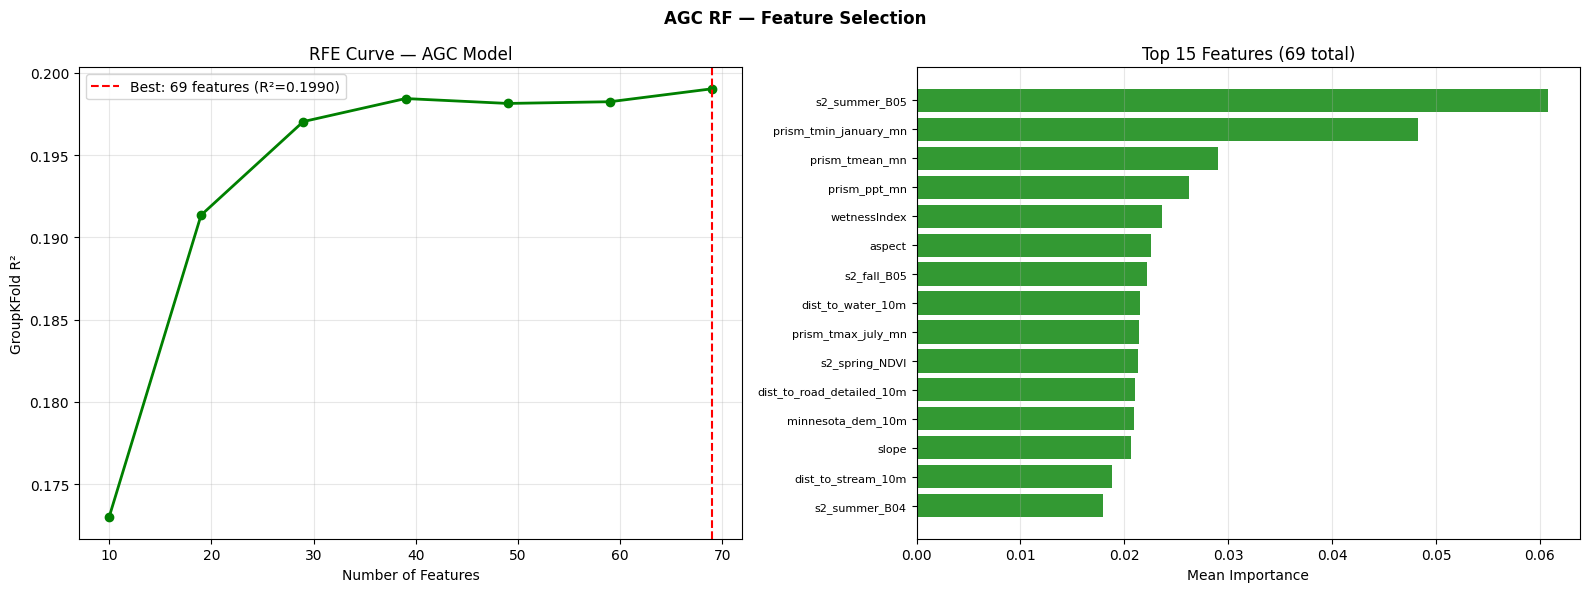

Top 5 features:
  s2_summer_B05: 0.0608
  prism_tmin_january_mn: 0.0483
  prism_tmean_mn: 0.0290
  prism_ppt_mn: 0.0262
  wetnessIndex: 0.0237


In [5]:
# Cell 4 — RFE curve and feature importance

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RFE curve
ax = axes[0]
ns  = [r['n_features'] for r in rfe['rfe_curve']]
r2s = [r['R2'] for r in rfe['rfe_curve']]
ax.plot(ns, r2s, 'o-', color='green', lw=2)
ax.axvline(rfe['n_features'], color='red', linestyle='--',
            label=f'Best: {rfe["n_features"]} features (R²={rfe["R2"]:.4f})')
ax.set_xlabel('Number of Features')
ax.set_ylabel('GroupKFold R²')
ax.set_title('RFE Curve — AGC Model')
ax.legend(); ax.grid(alpha=0.3)

# Feature importance from final model
ax = axes[1]
with open(f'{MDL_DIR}/agc_jenkins_rf_final.pkl','rb') as f:
    rf_final = pickle.load(f)
fi = pd.DataFrame({
    'feature':    best_features,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False).head(15)
ax.barh(range(len(fi)), fi['importance'].values[::-1],
         color='green', alpha=0.8)
ax.set_yticks(range(len(fi)))
ax.set_yticklabels([f[:40] for f in fi['feature'].values[::-1]], fontsize=8)
ax.set_xlabel('Mean Importance')
ax.set_title(f'Top 15 Features ({len(best_features)} total)')
ax.grid(alpha=0.3, axis='x')

plt.suptitle('AGC RF — Feature Selection', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RES_DIR}/agc_rfe_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5 features:')
for _, row in fi.head(5).iterrows():
    print(f'  {row["feature"]}: {row["importance"]:.4f}')


In [6]:
# Cell 5 — Performance by species group

print('CV performance by species group:')
print(f'{"Group":<20} {"n":>6}  {"R2":>8}  {"MAE":>8}  {"Mean obs":>10}  {"Mean pred":>10}')
print('-'*70)

df_res = df_train.copy()
df_res['oof'] = oof
df_res['residual'] = oof - y

for grp in df_res['JENKINS_GR'].unique():
    sub = df_res[df_res['JENKINS_GR']==grp]
    if len(sub) < 10: continue
    r2_g  = r2_score(sub[TARGET], sub['oof'])
    mae_g = mean_absolute_error(sub[TARGET], sub['oof'])
    print(f'{grp:<20} {len(sub):>6,}  {r2_g:>8.4f}  {mae_g:>8.4f}  '
          f'{sub[TARGET].mean():>10.3f}  {sub["oof"].mean():>10.3f}')

print()
print('=== INTERPRETATION ===')
print()
print(f'Overall R² = {r2:.4f} — the model explains {100*r2:.1f}% of variance in AGC')
print()
print('Why R² is low (~0.20):')
print('  1. Stand-level AGC is driven by species, age, and management history')
print('     — factors not fully captured by terrain/climate/spectral covariates')
print('  2. GroupKFold is honest — no leakage from same-polygon points')
print('     Standard random CV would give R²~0.6+ artificially')
print('  3. Training on all forest types (not just peatland forests) adds noise')
print('     since peatland forests are structurally different from upland forests')
print()
print(f'MAE = {mae:.4f} kgC/m2 = {mae*10:.2f} MgC/ha = {100*mae/y.mean():.1f}% of mean')
print('This is the expected error per pixel in the statewide prediction')
print()
print('Despite low R², the spatial pattern prediction is still useful:')
print('  - Climate and terrain gradients explain the broad pattern')
print('  - The model captures where AGC is likely HIGH vs LOW')
print('  - Uncertainty is acknowledged — this is a landscape-scale estimate')


CV performance by species group:
Group                     n        R2       MAE    Mean obs   Mean pred
----------------------------------------------------------------------
aspen                15,609    0.1002    1.3841       2.226       2.546
cedar_larch           4,683   -0.0627    1.4020       4.065       3.454
hard_maple            4,429   -0.2197    1.5461       4.438       3.490
mixed_hardwood        2,810   -0.1910    1.0741       3.043       2.870
none                    890   -4.9492    1.6228       0.570       2.105
pine                  3,546    0.0491    1.0102       2.406       2.740
soft_maple            1,383    0.0160    1.3313       3.436       3.029
spruce_fir           16,637    0.1562    1.2260       2.397       2.534

=== INTERPRETATION ===

Overall R² = 0.1990 — the model explains 19.9% of variance in AGC

Why R² is low (~0.20):
  1. Stand-level AGC is driven by species, age, and management history
     — factors not fully captured by terrain/climate/spectral 

In [7]:
# Cell 6 — Summary table for reporting

print('='*60)
print('AGC RF MODEL SUMMARY')
print('='*60)
print(f'Training data source:   DNR Forest Stand Inventory')
print(f'Target variable:        C_AGC_KGM2 (kgC/m²)')
print(f'Target derivation:      Jenkins et al. (2003) allometric equations')
print(f'                        QMD from BA + MN_DENS midpoints')
print(f'                        Carbon fraction = 0.5')
print(f'Training points:        {len(df_train):,} (50k subsample, stratified by species)')
print(f'Unique polygons:        {df_train["STAND_KEY"].nunique():,}')
print(f'CV method:              GroupKFold (n=5) by polygon ID')
print(f'Feature selection:      RFE — {len(best_features)} features selected from ~125')
print(f'N trees:                300')
print()
print(f'CV R²:                  {r2:.4f}')
print(f'CV MAE:                 {mae:.4f} kgC/m2  ({mae*10:.2f} MgC/ha)')
print(f'CV RMSE:                {np.sqrt(np.mean(residuals**2)):.4f} kgC/m2')
print(f'Relative MAE:           {100*mae/y.mean():.1f}% of mean')
print(f'Mean observed AGC:      {y.mean():.3f} kgC/m2  ({y.mean()*10:.1f} MgC/ha)')
print(f'Mean predicted AGC:     {oof.mean():.3f} kgC/m2  ({oof.mean()*10:.1f} MgC/ha)')
print()
print(f'Prediction mask:        exp410 >= 0.33')
print(f'Output:                 agc_rf_minnesota.tif (kgC/m²)')
print(f'Next step:              sbatch run_agc_rf_inference.sh')


AGC RF MODEL SUMMARY
Training data source:   DNR Forest Stand Inventory
Target variable:        C_AGC_KGM2 (kgC/m²)
Target derivation:      Jenkins et al. (2003) allometric equations
                        QMD from BA + MN_DENS midpoints
                        Carbon fraction = 0.5
Training points:        49,994 (50k subsample, stratified by species)
Unique polygons:        35,588
CV method:              GroupKFold (n=5) by polygon ID
Feature selection:      RFE — 69 features selected from ~125
N trees:                300

CV R²:                  0.1990
CV MAE:                 1.3063 kgC/m2  (13.06 MgC/ha)
CV RMSE:                1.7442 kgC/m2
Relative MAE:           48.1% of mean
Mean observed AGC:      2.714 kgC/m2  (27.1 MgC/ha)
Mean predicted AGC:     2.748 kgC/m2  (27.5 MgC/ha)

Prediction mask:        exp410 >= 0.33
Output:                 agc_rf_minnesota.tif (kgC/m²)
Next step:              sbatch run_agc_rf_inference.sh
